In [3]:
%pip install geopandas
%pip install matplotlib
import geopandas as gpd
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.5 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.5 MB 3.4 MB/s eta 0:00:03
   ----------- ---------------------------- 2.6/9.5 MB 3.8 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.5 MB 4.1 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.5 MB 4.2 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.5 MB 4.4 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.5 MB 4.4 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.5 MB 4.4 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.5 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 4.5 MB/s  0:00:02
   ------------------------------------

In [6]:
bikes = gpd.read_file("data/BikeInfrastructure.geojson")
requests = gpd.read_file("data/PublicServiceRequests.geojson")

In [7]:
bikes = bikes.to_crs("EPSG:2264")
requests = requests.to_crs("EPSG:2264")

In [8]:
bike_buffer = bikes.copy()

bike_buffer["geometry"] = bikes.buffer(1320)

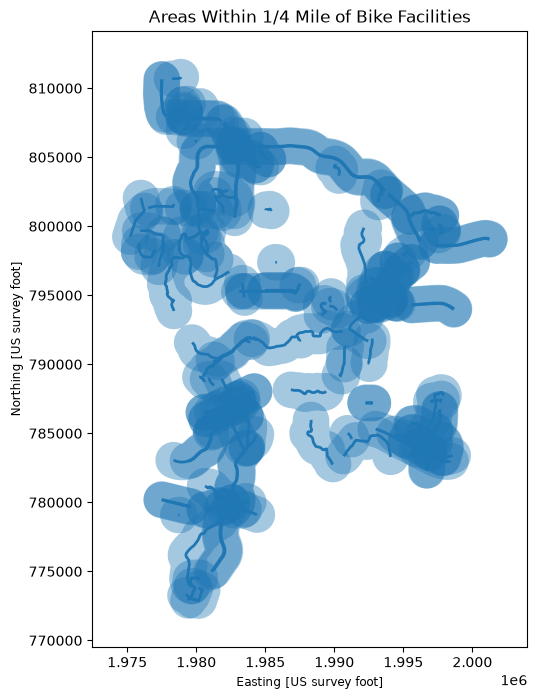

In [9]:
bike_buffer.to_file(
    "data/bike_buffer.geojson",
    driver="GeoJSON"
)

ax = bike_buffer.plot(
    figsize=(10, 8),
    alpha=0.4
)

bikes.plot(
    ax=ax,
    linewidth=2
)

plt.title("Areas Within 1/4 Mile of Bike Facilities")
plt.show()

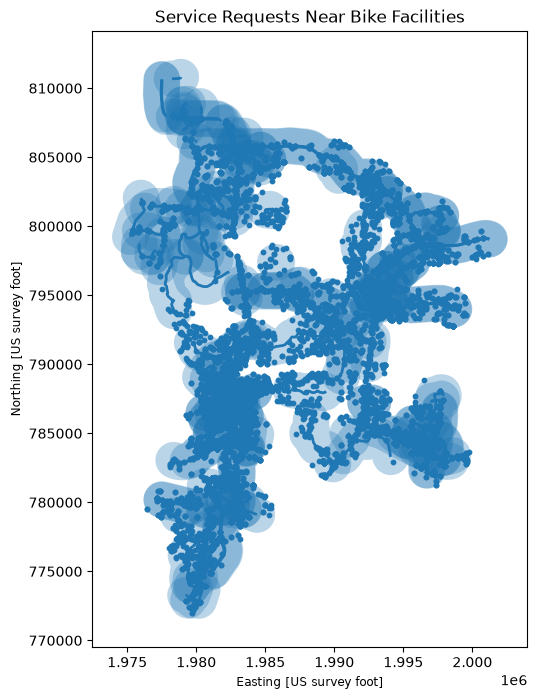

In [10]:
requests_near_bikes = gpd.sjoin(
    requests,
    bike_buffer,
    predicate="within",
    how="inner"
)

requests_near_bikes.to_file(
    "data/requests_near_bikes.geojson",
    driver="GeoJSON"
)

ax = bike_buffer.plot(
    figsize=(10, 8),
    alpha=0.3
)

bikes.plot(
    ax=ax,
    linewidth=2
)

requests_near_bikes.plot(
    ax=ax,
    markersize=10
)

plt.title("Service Requests Near Bike Facilities")
plt.show()

In [12]:
requests_join = gpd.sjoin(
    requests,
    bike_buffer,
    predicate="within",
    how="left"
)

requests_outside = requests_join[
    requests_join["index_right"].isna()
].copy()

requests_outside = requests_outside.drop(
    columns="index_right"
)

requests_nearest_bike = gpd.sjoin_nearest(
    requests_outside,
    bikes,
    how="left",
    distance_col="distance_ft"
)

requests_nearest_bike["distance_miles"] = (
    requests_nearest_bike["distance_ft"] / 5280
)


requests_nearest_bike.to_file(
    "data/requests_nearest_bike.geojson",
    driver="GeoJSON"
)

requests_nearest_bike[
    ["distance_ft", "distance_miles"]
].head()

,distance_ft,distance_miles
1,2445.534822,0.463169
6,1406.284751,0.266342
9,1477.929241,0.279911
21,1423.375779,0.269579
23,1336.639258,0.253151
